In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

In [2]:
np.random.seed(42)

In [3]:
def generate_samples(sample_size, delta, sigma, distribution):
    group_a = distribution(0, sigma, sample_size)
    group_b = distribution(delta, sigma, sample_size)
    return group_a, group_b

In [4]:
def run_pvalue_simulation(sample_size, delta, sigma, distribution, n_runs=1000):
    t_pvalues = np.empty(n_runs)
    mw_pvalues = np.empty(n_runs)

    for i in range(n_runs):
        a, b = generate_samples(sample_size, delta, sigma, distribution)

        _, t_p = ttest_ind(a, b, equal_var=False)
        _, mw_p = mannwhitneyu(a, b, alternative="two-sided")

        t_pvalues[i] = t_p
        mw_pvalues[i] = mw_p

    return t_pvalues, mw_pvalues

In [5]:
def compute_power(pvalues, alpha=0.05):
    return np.mean(pvalues < alpha)

In [6]:
sample_sizes = [20, 50, 100, 200, 500]
deltas = [0, 0.1, 0.2, 0.3, 0.4, 0.5]

In [7]:
def run_experiment(distribution, sigma=0.5, n_runs=1000):
    size_results = ([], [])
    delta_results = ([], [])

    for n in sample_sizes:
        t_p, mw_p = run_pvalue_simulation(
            n, delta=0.3, sigma=sigma, distribution=distribution, n_runs=n_runs
        )

        size_results[0].append(compute_power(t_p))
        size_results[1].append(compute_power(mw_p))

    for d in deltas:
        t_p, mw_p = run_pvalue_simulation(
            100, delta=d, sigma=sigma, distribution=distribution, n_runs=n_runs
        )

        delta_results[0].append(compute_power(t_p))
        delta_results[1].append(compute_power(mw_p))

    return size_results, delta_results

In [8]:
def plot_comparison(norm_size, norm_delta, lognorm_size, lognorm_delta):
    labels = ["t-тест", "критерий Манна-Уитни"]

    plt.figure(figsize=(13, 5))
    plt.subplot(1, 2, 1)

    for i, label in enumerate(labels):
        plt.plot(
            sample_sizes, norm_size[i], marker="o", label=f"Нормальное - {label}"
        )
        plt.plot(
            sample_sizes, lognorm_size[i], marker="o", label=f"Логнормальное - {label}"
        )

    plt.title(f"Мощность критериев от размера выборки")
    plt.xlabel("Объём выборки")
    plt.ylabel("Мощность")
    plt.xscale("log")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    for i, label in enumerate(labels):
        plt.plot(deltas, norm_delta[i], marker="o", label=f"Нормальное - {label}")
        plt.plot(
            deltas, lognorm_delta[i], marker="o", label=f"Логнормальное - {label}"
        )

    plt.title(f"Мощность критериев от различия средних")
    plt.xlabel("Дельта")
    plt.ylabel("Мощность")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [9]:
norm_size, norm_delta = run_experiment(np.random.normal)

In [10]:
lognorm_size, lognorm_delta = run_experiment(np.random.lognormal)

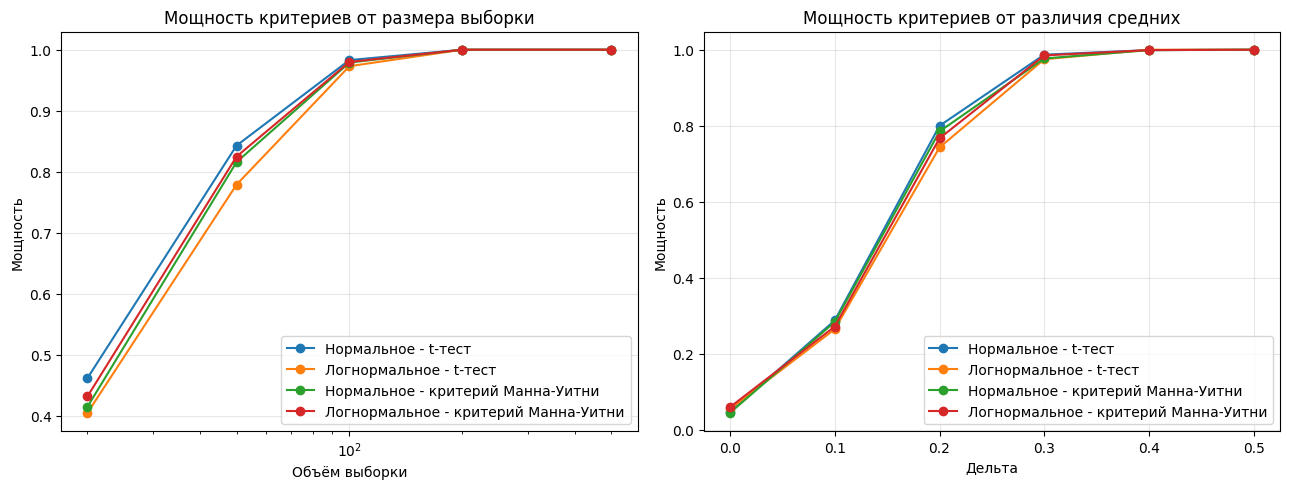

In [11]:
plot_comparison(norm_size, norm_delta, lognorm_size, lognorm_delta)